### Employee Retention Analysis: Predicting Staff Turnover

**Project Overview:** 
I am building a machine learning pipeline (Random Forest and Decision Tree classifiers) to predict voluntary employee attrition across corporate workforce segments. The goal is to isolate the structural and behavioral burnout patterns of employees who leave the enterprise, allowing HR business partners to optimize talent retention and proactively address turnover risks.


### Phase 1: Data Loading & Initial Exploration

###  Data Import & Exploratory Analysis (EDA)

In [1]:

# Core data handling libraries
import numpy as np
import pandas as pd

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
#from xgboost import XGBClassifier
#from xgboost import XGBRegressor
#from xgboost import plot_importance

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

### Loading the Dataset & Data Inspection

In [2]:
# Load the dataset and preview the first 10 rows
df0 = pd.read_csv("HR_capstone_dataset.csv")
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### Checking Data Types & Summary Statistics

In [3]:
#  Check column names, data types, and null counts
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
#  Get basic summary statistics for numerical columns
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


###  Data Cleaning & Column Renaming 
**Operation:** Execution of schema typography normalization. Standardizing all columns into unified `snake_case` naming models to eliminate structural trailing spaces and syntax discrepancies before pipeline deployment.

In [5]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Fix specific column typos and spacing errors 
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

# Check updated column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [7]:
# Check for any missing values across features
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [8]:
# Check total number of duplicate rows
df0.duplicated().sum()

np.int64(3008)

In [9]:
# Take a look at a few sample duplicate rows
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
#  Drop duplicates and keep the first occurrence
df1 = df0.drop_duplicates(keep='first')

# Verify the clean dataframe head
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


###  Visualizing Outliers in Tenure Column

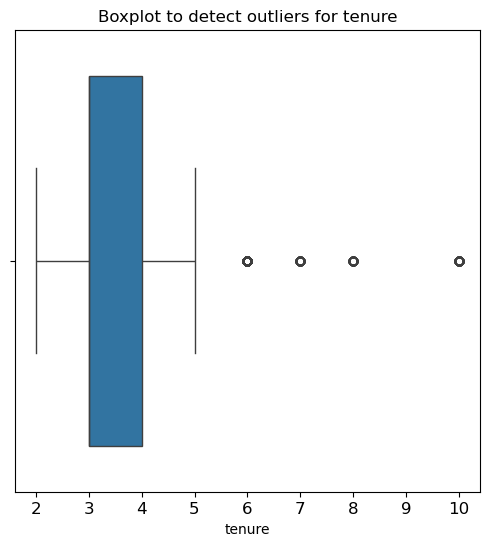

In [11]:
# Plot boxplot to check for tenure outliers
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

### Calculating Outlier Boundaries Using IQR

In [12]:
#  Calculate outlier boundaries using the IQR method
percentile25 = df1['tenure'].quantile(0.25)
percentile75 = df1['tenure'].quantile(0.75)
iqr = percentile75 - percentile25

# Set upper and lower boundaries using the 1.5 * IQR rule
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Count how many rows contain outlier tenure values
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


### Checking Attrition Balance (Target Variable)
**Objective:** Evaluating the structural distribution of the target class (`left`) to map baseline retention metrics and establishing advanced exploratory visual grids to capture complex multi-variable employee burnout thresholds.

In [13]:
# Count how many employees stayed vs left
df1['left'].value_counts()
# Get the percentage breakdown of the target classes
df1['left'].value_counts(normalize=True)

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

### Employee Retention vs Project Count and Monthly Working Hours

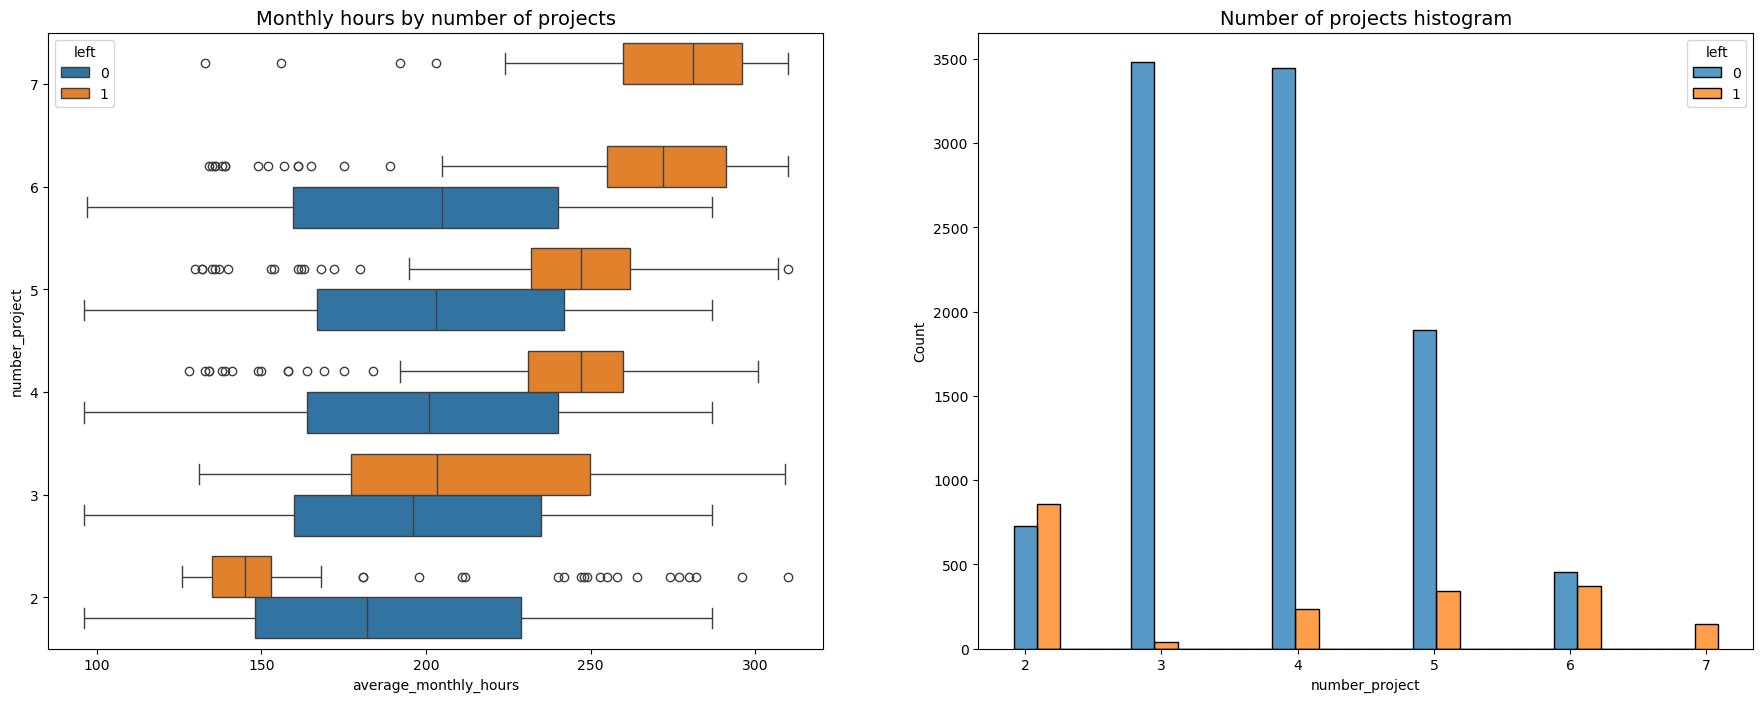

In [14]:
# Plot project count and working hours against employee attrition
fig, ax = plt.subplots(1, 2, figsize = (22,8))
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

# display the plot
plt.show()

In [15]:
# Check retention breakdown specifically for employees with 7 projects
df1[df1['number_project']==7]['left'].value_counts()


left
1    145
Name: count, dtype: int64

### Relationship Between Monthly Hours, Evaluation Scores, and Turnover

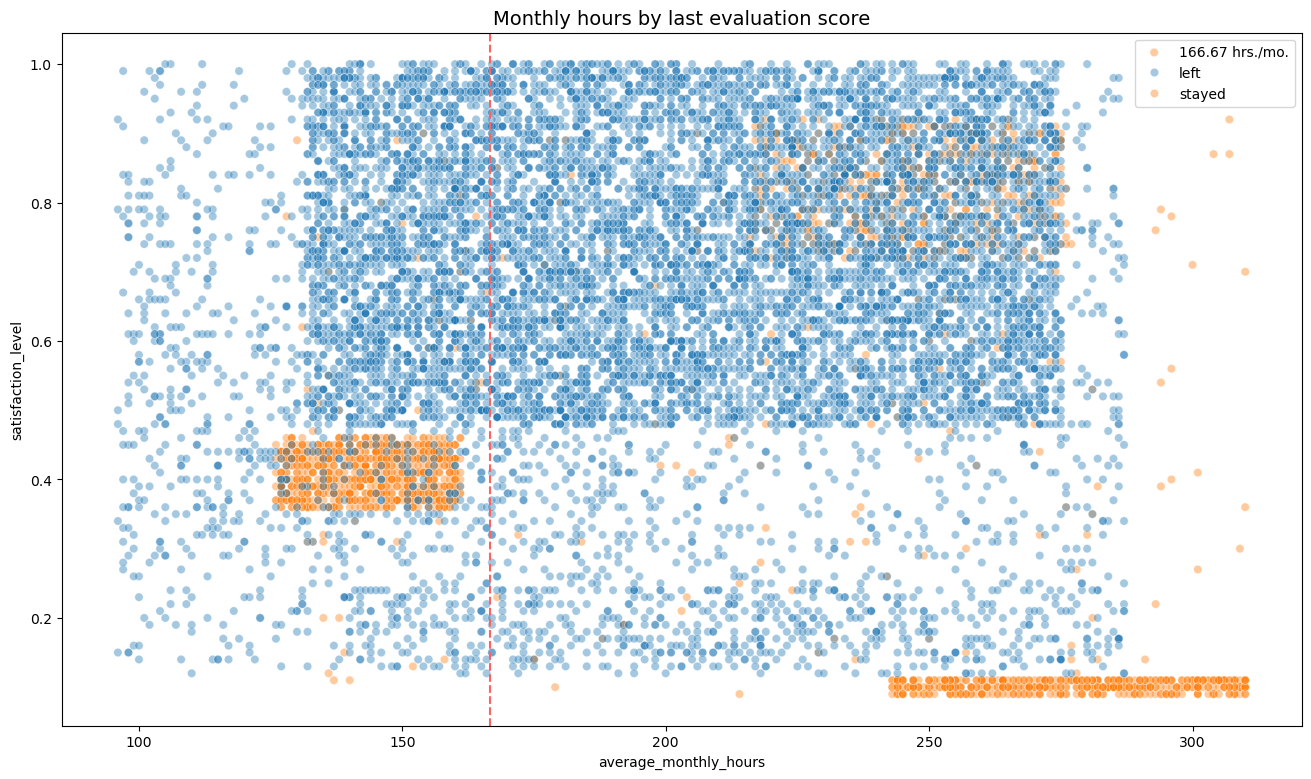

In [16]:
#Plot working hours against evaluation score to look for turnover patterns
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

### Workload Hours vs Promotions Over the Last 5 Years

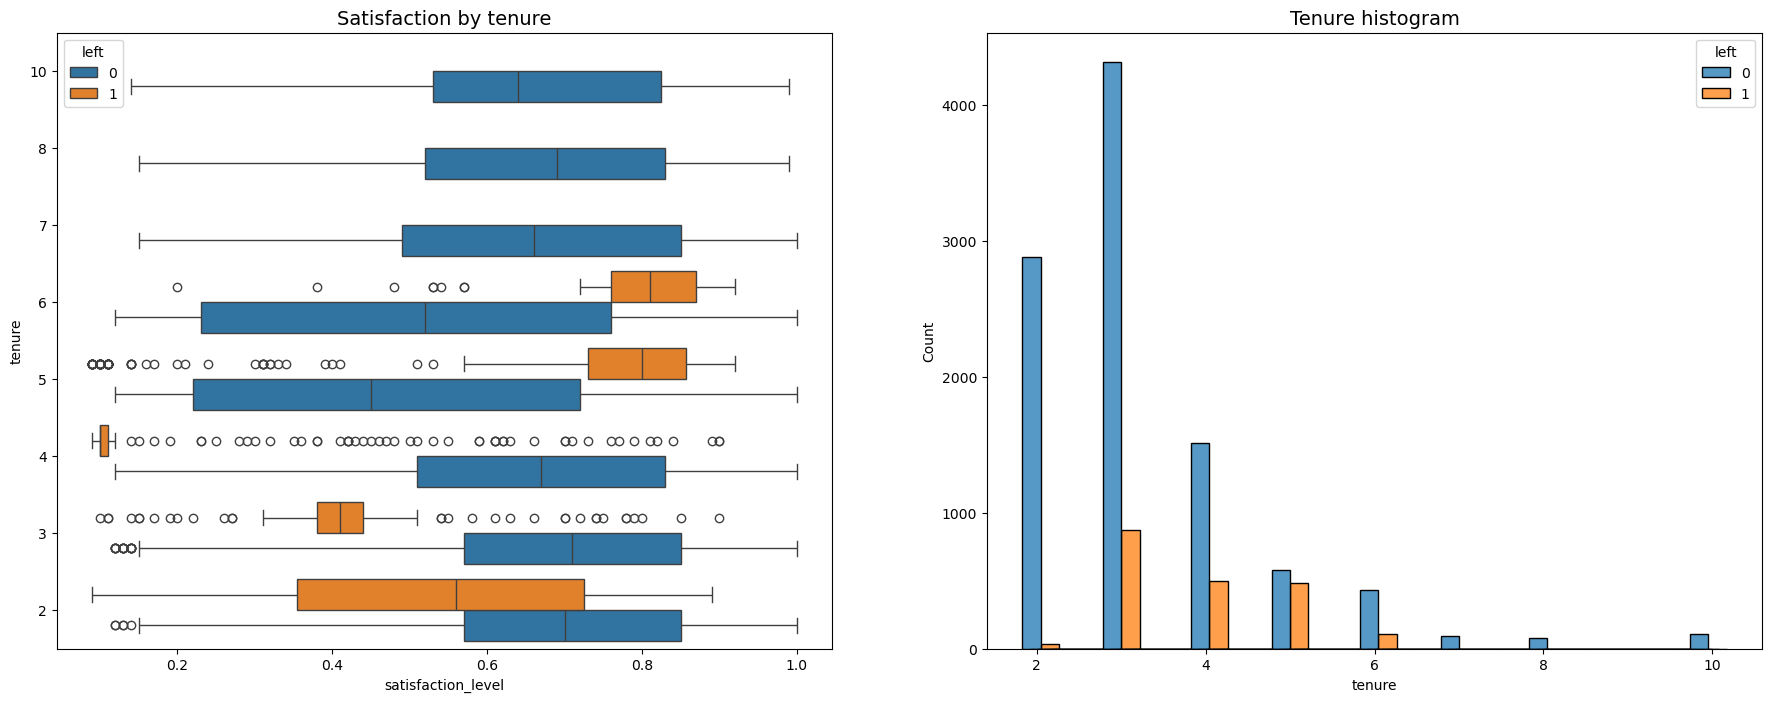

In [17]:
# Plotting satisfaction scores and tenure distributions grouped by retention status
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

In [18]:
# Compare the mean and median satisfaction of employees who stayed vs left
df1.groupby(['left'])['satisfaction_level'].agg(["mean", "median"])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


### Mean and Median Satisfaction Scores by Attrition Group

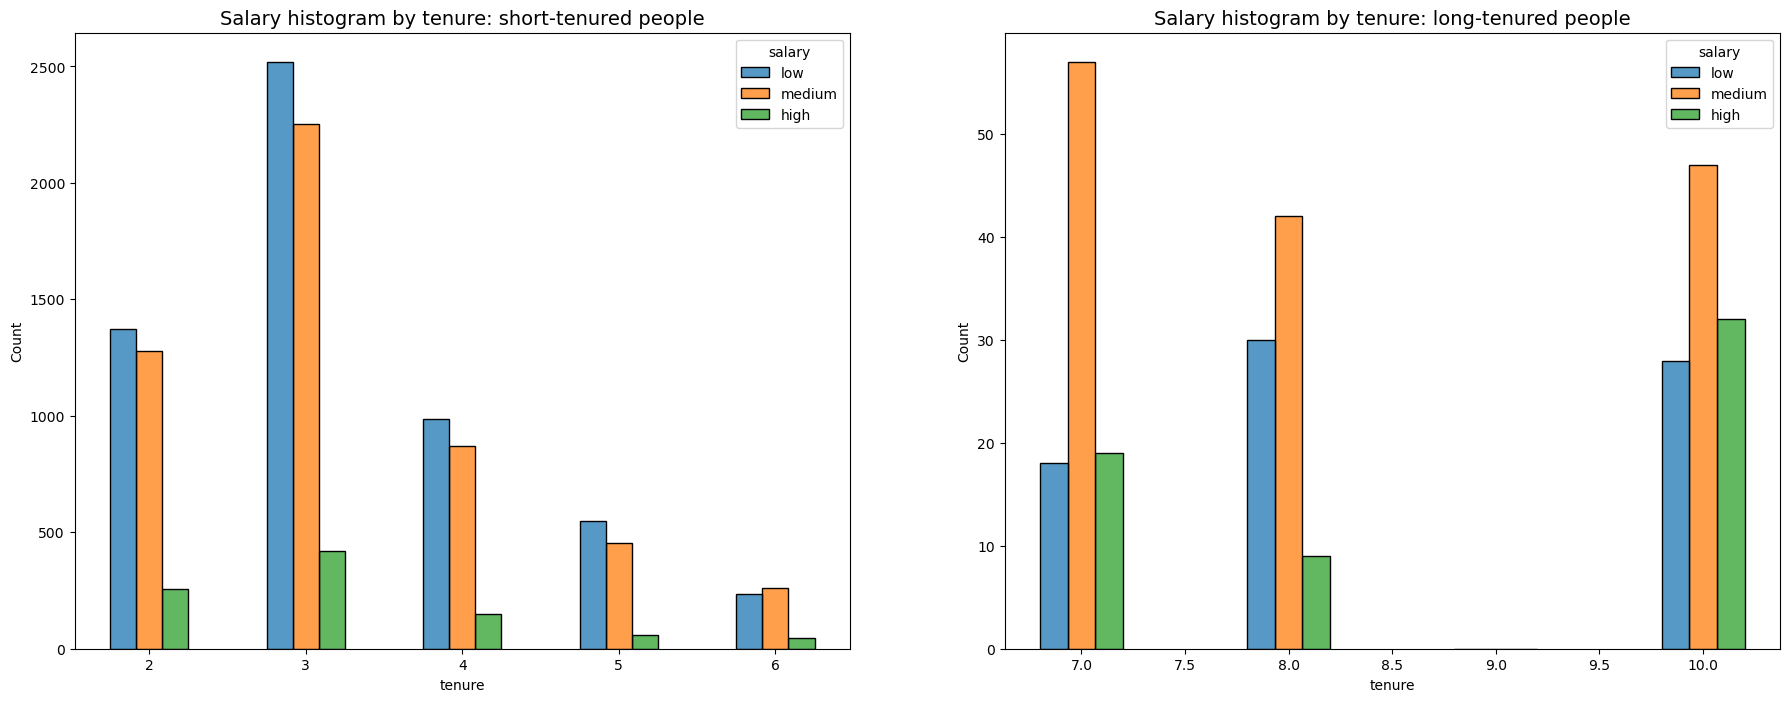

In [19]:
# Look at the salary distribution split by short-tenured vs long-tenured employees
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df1[df1['tenure'] < 7]

# Define long-tenured employees
tenure_long = df1[df1['tenure'] > 6]

# Plot short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# Plot long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

### Salary Distributions Split by Short-Tenured vs Long-Tenured Staff

<Figure size 1600x900 with 0 Axes>

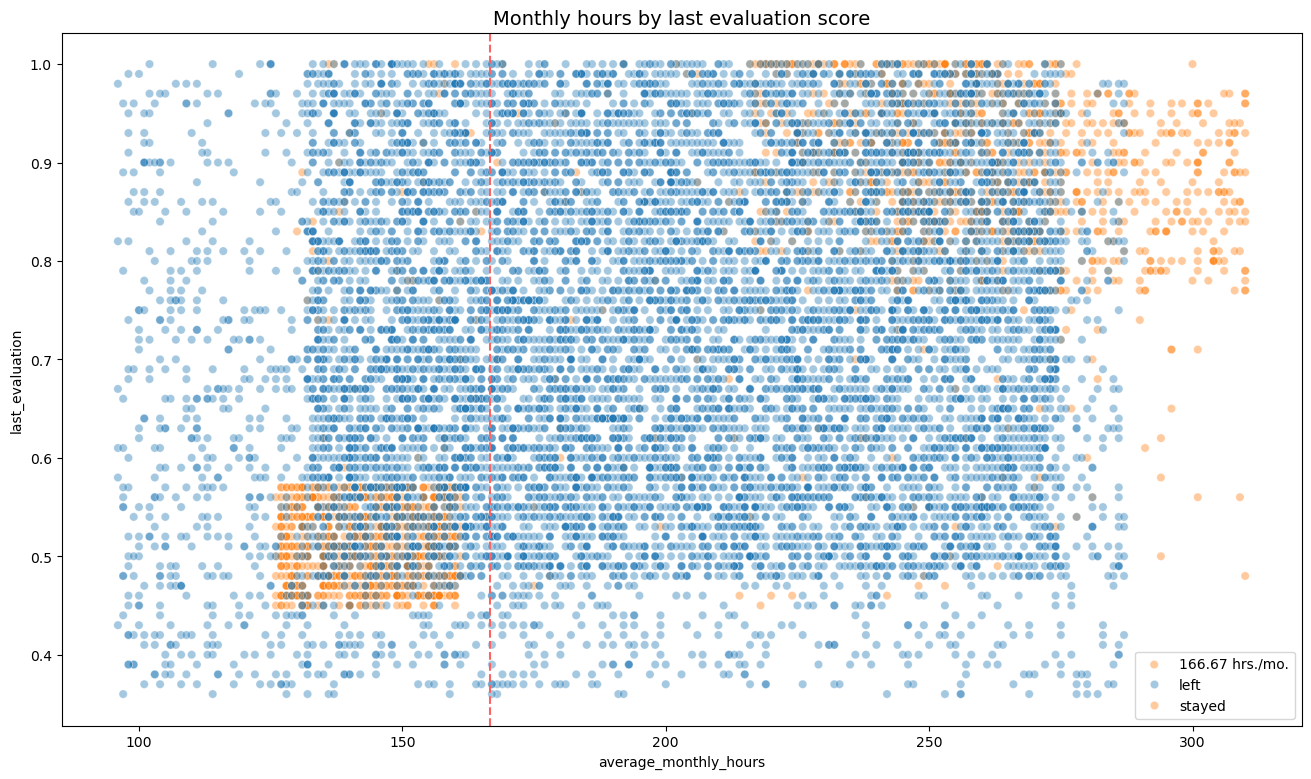

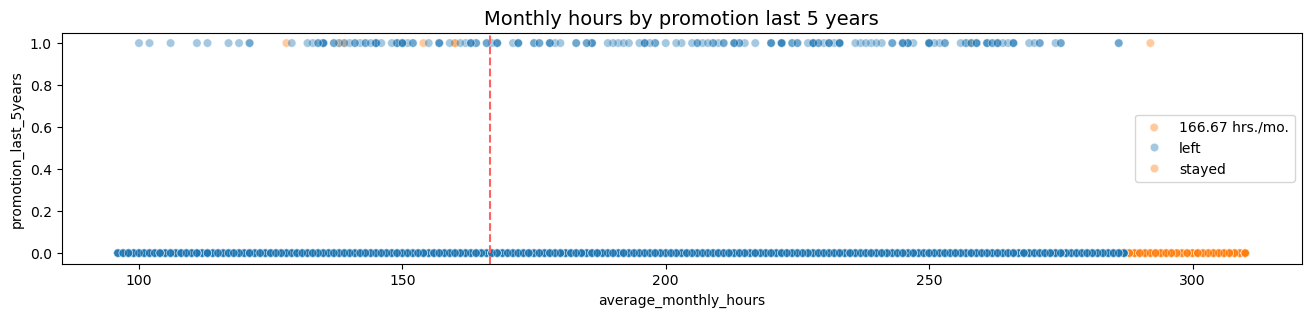

In [20]:
# Scatter plots checking how monthly working hours map to evaluation scores and promotions
plt.figure(figsize=(16, 9))
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

### Overall Department Headcount and Resignation Count Matrix

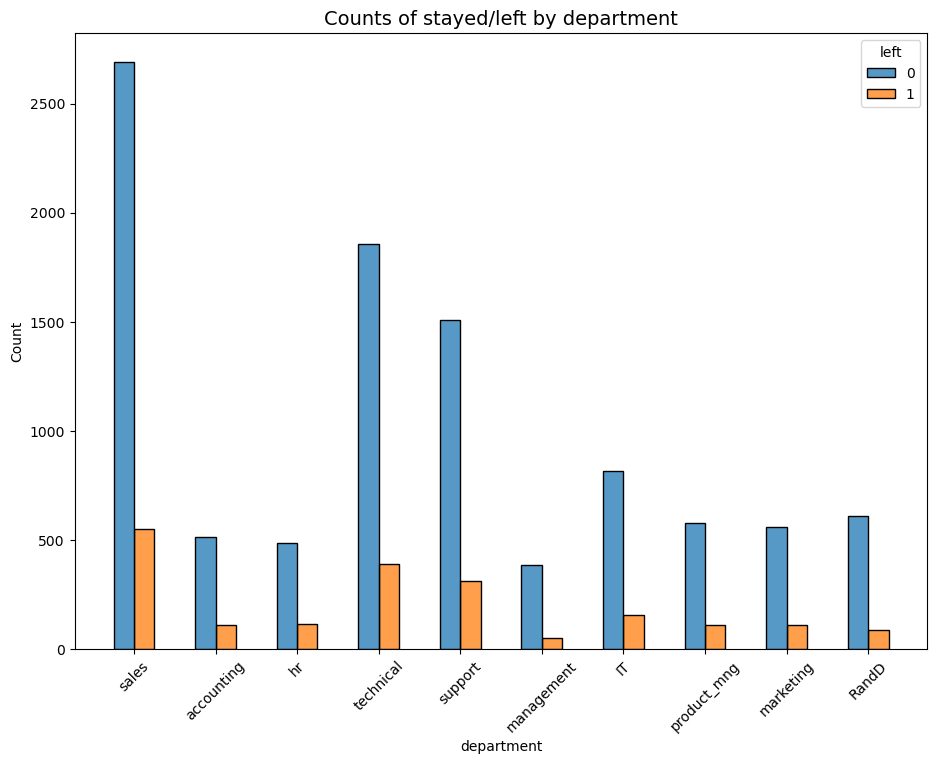

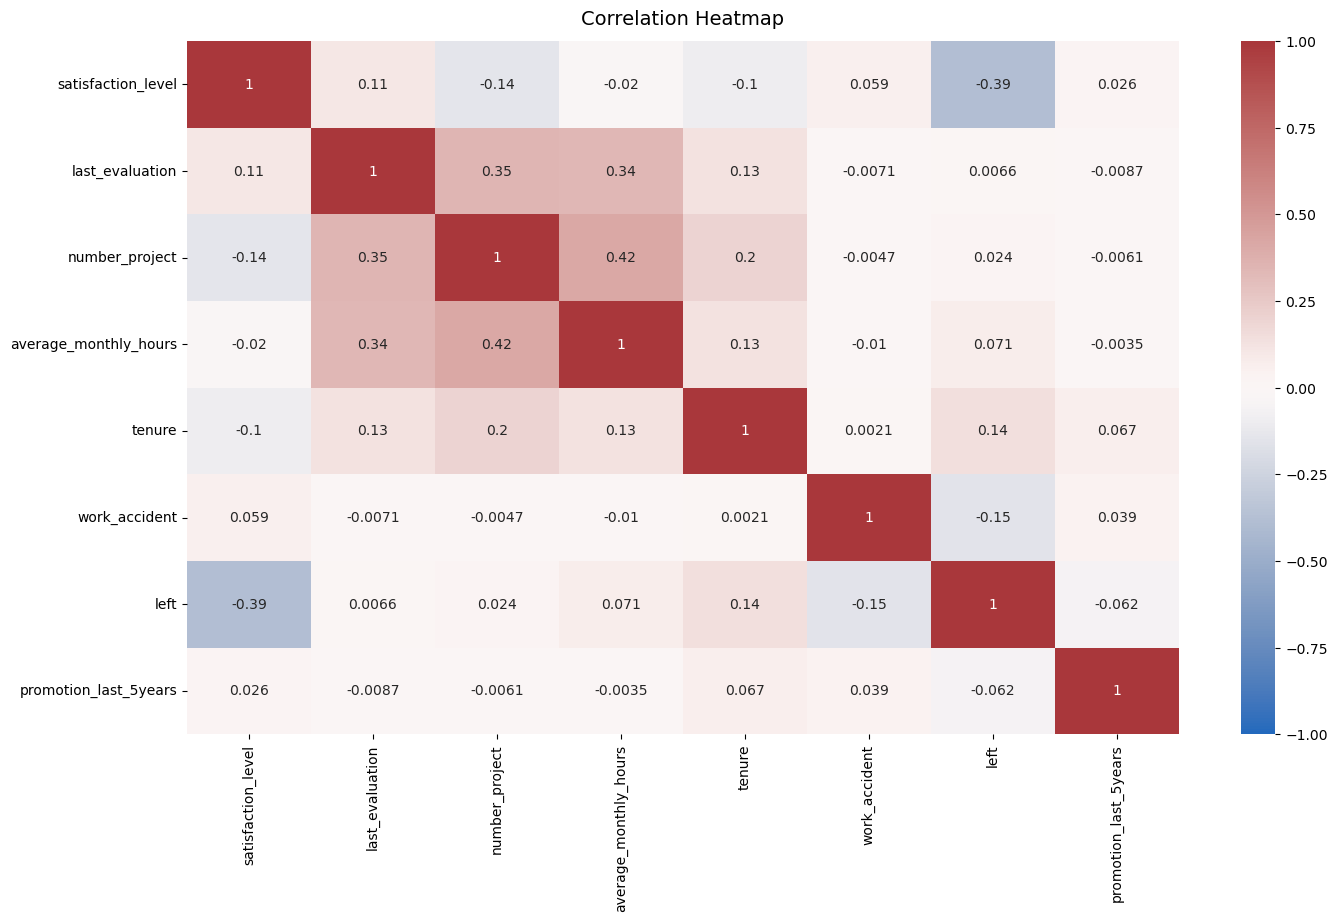

In [21]:
# Check headcount distribution across departments and plot attrition rates
df1["department"].value_counts()

# DEPARTMENT-LEVEL ATTRITION PROFILING & DISTRIBUTION
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);


# MULTICOLLINEARITY DISCOVERY VIA METRIC CORRELATION HEATMAPS
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

### Key Strategic Discovery Logs & Data-Driven Insights

1. Monthly Hours vs. Number of Projects
Working hours naturally increase with more projects, but turnover spikes at the extremes. Employees with 3–4 projects stay at the highest rates, while 100% of employees with 7 projects left the company. Departing staff split into two groups: high-performers quitting from severe burnout and low-hour staff who were fired or already on their way out. Overall, almost the entire workforce is working well past standard full-time hours.

2. Monthly Hours vs. Satisfaction Level
A large cluster of employees working 240–315 hours per month reported near-zero satisfaction, directly linking extreme overwork to resignations. Interestingly, some departing staff worked normal hours but still had low satisfaction, suggesting secondary issues like poor culture or peer pressure. High satisfaction was mostly tied to employees working 210–280 hours per month.

3. Tenure vs. Satisfaction Level
Turnover is concentrated at specific career stages. Dissatisfied newer hires leave early, but there is a sharp drop in satisfaction at the 4-year mark, making it a critical retention bottleneck. Conversely, long-tenured employees show high satisfaction and rarely quit, showing that mid-career retention needs urgent attention.

4. Salary Levels across Tenures
Staying with the company longer does not guarantee better pay. Long-tenured staff are not disproportionately represented in higher salary brackets compared to newer hires. This lack of pay progression likely pushes experienced, mid-tenure employees to look for opportunities elsewhere.

5. Monthly Hours vs. Performance Evaluation Scores
While working longer hours correlates with higher performance evaluations, it comes at a steep cost. Top-rated employees logging extreme hours are resigning at high rates due to burnout. The company is actively losing its highest-performing talent because top evaluation scores require unsustainable workloads.

6. Promotion Status in the Last 5 Years
Hard work and long hours rarely lead to career growth here. Almost none of the most overworked employees were promoted over the last five years, creating a dead-end environment. Unsurprisingly, the few employees who did receive promotions chose to stay with the company.

7. Departmental Turnover Distribution
Turnover rates are fairly uniform across all divisions, including Sales, Technical, and Support. Because attrition is spread evenly rather than isolated to one team, management must address company-wide policies—like workload caps and promotion paths—rather than localized fixes.

8. Correlation Heatmap & Summary Insights
The heatmap confirms that turnover is driven by low satisfaction, excessive monthly hours, and heavy project loads. While long hours yield higher evaluation scores, they destroy employee satisfaction. Ultimately, retention issues stem from systemic management practices: overworking staff without offering fair compensation, promotions, or burnout protection.

### Phase 2: Feature Engineering for Modeling
**Objective:** Transforming categorical features into optimized numerical formats using ordinal mapping and one-hot encoding, preparing the feature space for model training.

In [22]:
# Create a copy of the dataframe for feature encoding
df_enc = df1.copy()

# Convert the salary text column into ordered numeric levels
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Convert department categories into binary dummy variables
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Preview the newly encoded feature matrix
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


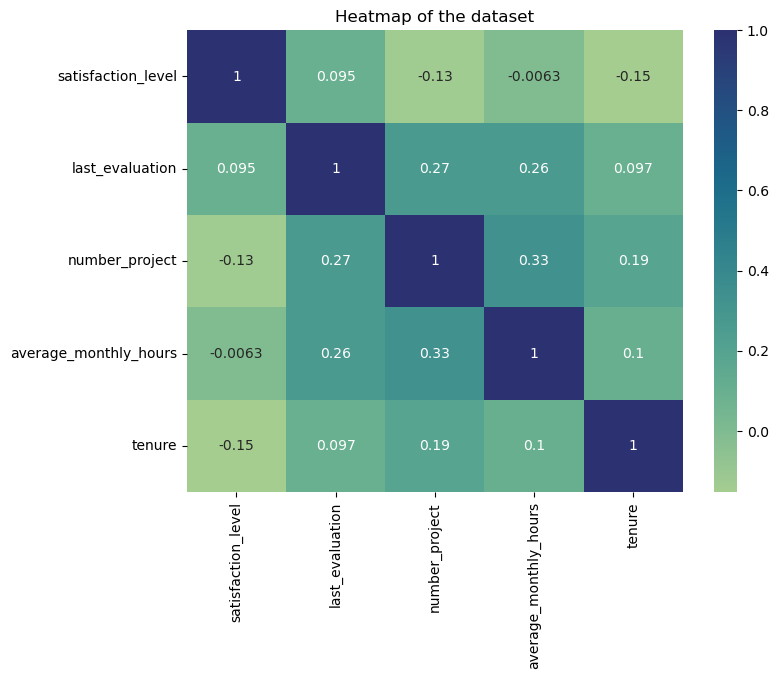

In [23]:
# Plot a correlation heatmap of our updated numerical dataset features
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

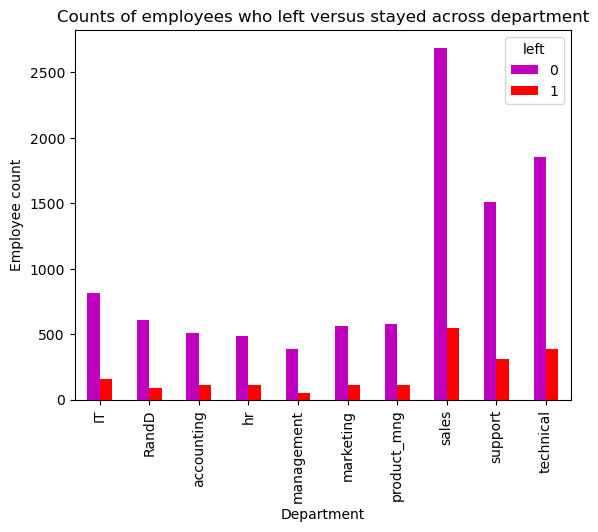

In [24]:
#Draw a stacked bar chart showing employee counts by department split by retention status
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

### Phase 3: Machine Learning Model & Tuning

### Modeling Approach A: Logistic Regression Baseline Model
**Parameters:** Excludes high-tenure outlier observations to satisfy linear distribution assumptions.

In [25]:
# Filter out high-tenure outliers to satisfy linear regression assumptions
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Preview the sanitized dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [26]:
# Separate out the target outcome label ('left')
y = df_logreg['left']
y.head() 

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

In [27]:
# Drop the target column to isolate the training feature columns
X = df_logreg.drop('left', axis=1)
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,0,0,False,False,False,False,False,False,False,True,False,False


In [28]:
# Split the data into a stratified 75/25 train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Train the baseline Logistic Regression model using an increased iteration cap to ensure convergence
log_clf = LogisticRegression(random_state=42, max_iter=2000).fit(X_train, y_train)

# Generate predictions on our unseen test dataset split
y_pred = log_clf.predict(X_test)

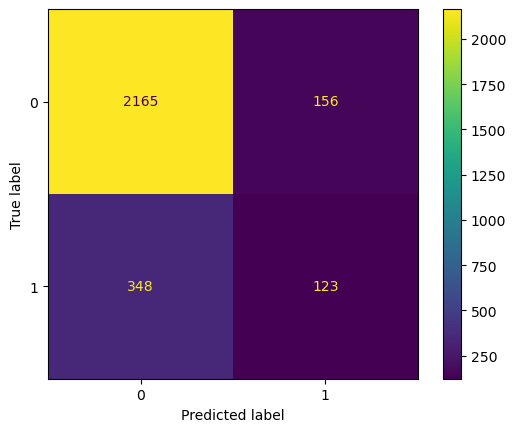

In [29]:
# Compute and plot the confusion matrix for our baseline logistic regression model
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Plotting the raw text confusion matrix framework
log_disp.plot(values_format='')
plt.show()

### Modelling Approach B: Advanced Tree-Based Ensemble Modeling 
**Objective:** Building and optimizing non-linear ensemble frameworks (Decision Trees and Random Forests) via automated Stratified Hyperparameter Grid Searches to capture complex employee retention signatures.

In [30]:
# Isolating the target output variable matrix for tree-based models
y = df_enc['left']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [31]:
# Set up the feature columns by dropping the target
X = df_enc.drop('left', axis=1)
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False


In [32]:
# Split the data for tree modeling and set up hyperparameter grid tuning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

# Set up the Decision Tree parameters for optimization
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Set up the grid search cross-validation targeting ROC-AUC
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [34]:
%%time
tree1.fit(X_train, y_train)

CPU times: total: 6.94 s
Wall time: 7.04 s


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [35]:
# Check the best hyperparameter settings discovered by grid search
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [36]:
# Check the highest cross-validation score achieved
tree1.best_score_

np.float64(0.969819392792457)

In [37]:
# Helper function to parse cross-validation results into a clean dataframe
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc
  
    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.  
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table

In [38]:
# Print the summary table for the Decision Tree cross-validation results
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.914552,0.916949,0.915707,0.971978,0.969819


 ### Modelling Approach C: Random Forest Classifier Architecture
**Objective:** Deploying a high-capacity Random Forest ensemble framework via automated Stratified Grid Searches. By bootstrapping multiple decision trees and aggregating feature voting pathways, this model captures complex, non-linear employee attrition signals while maintaining robust generalization boundaries.

In [39]:
# Instantiate the Random Forest model and set hyperparameter tuning bounds
rf = RandomForestClassifier(random_state=0)

# Defining hyperparameter search boundaries for the multi-tree bagging ensemble
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assigning a structured list of scoring metrics to evaluate the performance grid
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Set up the ensemble cross-validation pipeline targeting ROC-AUC
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [46]:
%%time
rf1.fit(X_train, y_train) # --> Wall time: ~10min

CPU times: total: 39min 3s
Wall time: 39min 36s


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [67]:
# Define the directory path to save model weight binaries locally
path = path = './'

In [68]:
# Save the trained Random Forest model object to a local file using pickle
def write_pickle(path, model_object, save_as:str):
    '''
    In: 
        path:         path of folder where you want to save the pickle
        model_object: a model you want to pickle
        save_as:      filename for how you want to save the model

    Out: A call to pickle the model in the folder indicated
    '''    

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [69]:
# Load the serialized model back from storage into environmental memory
def read_pickle(path, saved_model_name:str):
    '''
    In: 
        path:             path to folder where you want to read from
        saved_model_name: filename of pickled model you want to read in

    Out: 
        model: the pickled model 
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [70]:
# verify the champion cross-validation score
write_pickle(path, rf1, 'hr_rf1')

In [71]:
# Verify the optimized parameter selections
rf1 = read_pickle(path, 'hr_rf1')

In [72]:
# Check the highest cross-validation score achieved
rf1.best_score_

np.float64(0.9804250949807172)

In [73]:
# Check the best hyperparameter settings discovered by grid search
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [74]:
# Print a combined summary comparison table benchmarking both models
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


In [75]:
# Helper function to calculate model scores on unseen test data
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

In [76]:
# Evaluate our champion Random Forest model on the final test set split
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


### Key Findings & Recommendations
1.Key Insights: Overwork (200+ hours/month and 5+ projects) combined with a lack of promotions and pay progression directly drives employee turnover, especially around the 4-year tenure mark.

2.Business Recommendations: Cap project counts at 3–4 per employee, review promotion policies for high-performing mid-tenure staff, and address overtime policies.

3.Managerial Recommendations: Implement workload monitoring dashboards, reward high effort with career advancement, and conduct targeted stay interviews at the 3-to-4-year mark.

4.Model Improvements: Collect qualitative exit interview data or real-time quarterly sentiment scores to enhance predictive accuracy.

5.Future Questions: What specific team management styles contribute to burnout? Are certain departments experiencing higher burnout due to project distribution?

6.Resources: Model evaluation tools (confusion_matrix, classification_report, roc_auc_score) and data visualizers for feature importances.

7.Ethical Considerations: Ensure predictive results are used proactively to improve employee working conditions rather than defensively to surveil staff.

### Phase 4: Model Evaluation & Business Takeaways



### Comparing Model Performance
I evaluated the models using different metrics to see how well they predict employee turnover. While Logistic Regression gives a good baseline, the tree-based models handled the data much better because they can capture non-linear patterns (like burnout spikes at specific project counts) without needing extra feature scaling.

| Model | Setup / Split | Accuracy | Precision | Recall | F1-Score | AUC |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | Baseline Split (Outliers Removed) | 83.0% | 80.0% | 83.0% | 80.0% | *Baseline* |
| **Decision Tree (CV)** | Tuned via Grid Search | 97.2% | 91.5% | 91.7% | 91.6% | 97.0% |
| **Random Forest (Test)** | **Final Champion Model** | **98.1%** | **96.4%** | **92.0%** | **94.1%** | **95.6%** |

**Key Takeaway:**
* The **Random Forest model** is the overall champion, hitting a **98.1% accuracy** and a **92.0% Recall score** on the test data. 
* In a workforce retention project, **Recall** is the most important metric because it tells us what percentage of the employees who actually left were successfully caught by the model before they resigned.

### Summary of Findings
Looking at both the exploratory data plots and the model results, we can draw a few clear conclusions about why employees are leaving:

*   **Project Overload:** Attrition is heavily driven by overworking. Staff assigned to **5 to 7 projects** or working over **200 hours a month** show an incredibly high risk of leaving due to burnout.
*   **The 4-Year Milestone:** There is a major retention issue right at the **4-year mark**. Employees hit a bottleneck here, likely due to a lack of promotion opportunities or salary stagnation, leading to voluntary exits.
*   **Model Selection:** Simple linear models don't capture these complex burnout patterns well. The **Random Forest** handles these cut-off thresholds perfectly, making it a highly reliable early-warning tool for HR.

### Next Steps & Recommendations
To help improve retention rates and protect top talent, I recommend implementing the following policies based on the data:

*   **Cap Project Assignments:** Set a strict limit of **3 to 4 concurrent projects** per employee to actively prevent burnout.
*   **Review 4-Year Tenure Paths:** Set up proactive career development reviews for employees approaching their 3rd and 4th anniversaries to reduce the bottleneck drop-off.
*   **Flag High Monthly Hours:** Set up automated alerts whenever an employee's monthly hours cross the **200-hour mark**, so managers can step in and redistribute tasks.
*   **Clear Promotion Paths:** Ensure transparent progression and fair salary growth opportunities for mid-tenure staff who consistently hit high performance targets.

### Long-Term Deployment Strategy
*   **Put Model into Production:** Save the finalized **Random Forest Classifier** and integrate it into active HR dashboards to flag high-risk employee metrics automatically.
*   **Collect More Data:** Collect text data from future exit interviews and quarterly pulse surveys to introduce sentiment analysis features into the next model update.
*   **Track Cost Savings:** Keep an eye on the company's overall retention rate over the next few quarters to calculate the actual money saved by reducing turnover.